In [5]:
%pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 163.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [boto3]32m2/5 [botocore]
Note: you may need to restart the kernel to use updated packages.


In [42]:
from IPython.display import Image, display

In [6]:
import boto3

In [7]:
#Setting up the client object instance
client = boto3.client("bedrock-runtime", region_name = "us-west-2")

# Setting up the model ID -> Important to know the difference between model id and inference id
# model id can be available in a region but not in other, hence leverage inference profile
# Here to start with we are using model id
model_id = "us.anthropic.claude-sonnet-4-20250514-v1:0"

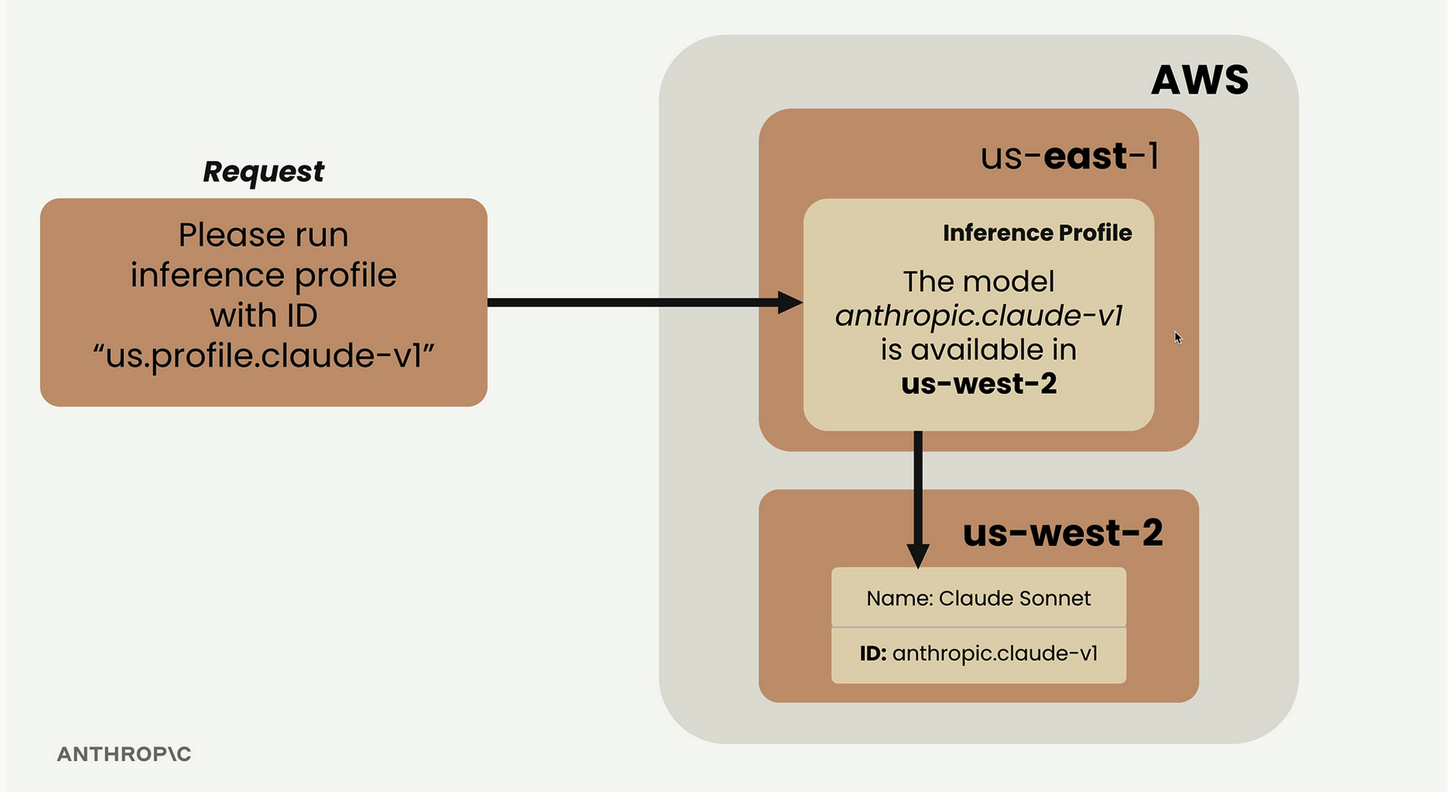

In [48]:
display(Image(filename="images/inference_profile.png"))

```User messages have a specific structure that might look overly complex at first, but there's a good reason for it:The content is a list because a single message can contain different types of content - text, images, or other media types. This structure allows you to send multimodal requests.```

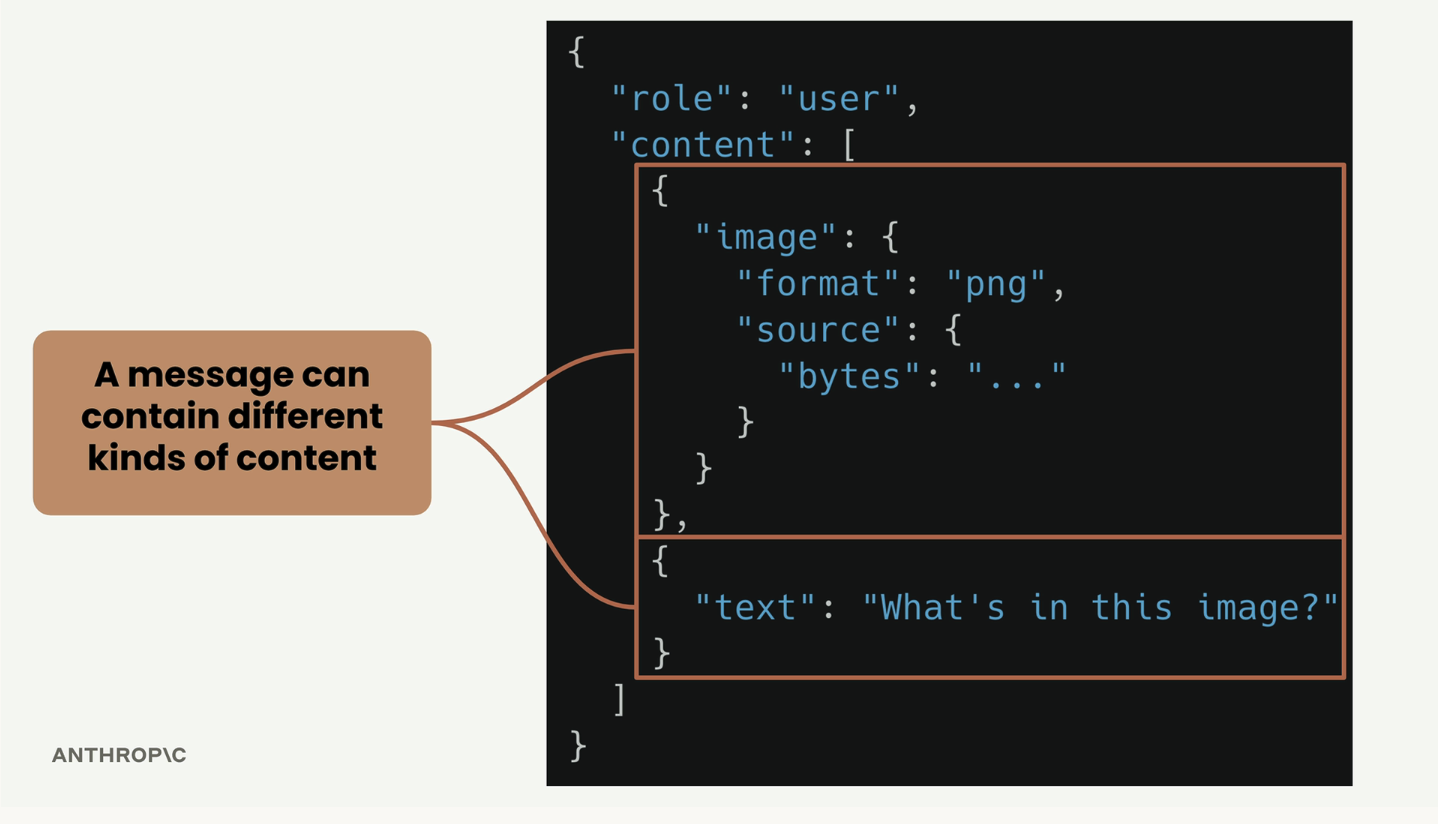

In [47]:
display(Image(filename="images/message_format.png"))

In [46]:

user_message = {
    "role": "user",
    "content": [
        { "text": "Who are you?" }
    ]
}

In [28]:
response = client.converse(
    modelId=model_id , 
    messages=[user_message] # it can ingest a list of message
)

In [29]:
response

{'ResponseMetadata': {'RequestId': 'b30488ec-b097-42b4-bc1e-fcbaadef3e05',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'date': 'Mon, 25 Aug 2025 13:00:32 GMT',
   'content-type': 'application/json',
   'content-length': '566',
   'connection': 'keep-alive',
   'x-amzn-requestid': 'b30488ec-b097-42b4-bc1e-fcbaadef3e05'},
  'RetryAttempts': 0},
 'output': {'message': {'role': 'assistant',
   'content': [{'text': "I'm Claude, an AI assistant created by Anthropic. I'm here to help with a wide variety of tasks like answering questions, helping with analysis and research, creative projects, math and coding, and having conversations. Is there something specific I can help you with today?"}]}},
 'stopReason': 'end_turn',
 'usage': {'inputTokens': 11,
  'outputTokens': 60,
  'totalTokens': 71,
  'cacheReadInputTokens': 0,
  'cacheWriteInputTokens': 0},
 'metrics': {'latencyMs': 3058}}

In [39]:
response['output']

{'message': {'role': 'assistant',
  'content': [{'text': "I'm Claude, an AI assistant created by Anthropic. I'm here to help with a wide variety of tasks like answering questions, helping with analysis and research, creative projects, math and coding, and having conversations. Is there something specific I can help you with today?"}]}}

In [40]:
response['output']['message']

{'role': 'assistant',
 'content': [{'text': "I'm Claude, an AI assistant created by Anthropic. I'm here to help with a wide variety of tasks like answering questions, helping with analysis and research, creative projects, math and coding, and having conversations. Is there something specific I can help you with today?"}]}

In [41]:
response['output']['message']['content'][0]['text']

[{'text': "I'm Claude, an AI assistant created by Anthropic. I'm here to help with a wide variety of tasks like answering questions, helping with analysis and research, creative projects, math and coding, and having conversations. Is there something specific I can help you with today?"}]